# Example: Spectral-Assisted LAP Tracking Analysis

This notebook demonstrates the spectral-assisted LAP (Linear Assignment Problem) tracker
for linking single-molecule localisations across frames using both spatial proximity
and colour (spectral) information.

**Input:** `.h5` localisation database produced by `SR_Functions.fit_SM_data()` or similar,
containing columns: `frame, xc, yc, s_x, s_y, bg_B, bg_G, bg_R, A_B, A_G, A_R, chi_sqr`
and corresponding error columns.

**Algorithm:** Jaqaman et al. (2008) Nat. Methods 5, 695-702, extended with spectral
distance in normalised RGB space.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys

sys.path.append("../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import SM_extractionfunctions
SM_E = SM_extractionfunctions.extract_SMs()

from src import HelperFunctions
H_F = HelperFunctions.Helper_Functions()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter()

from copy import copy

import DriftCorrectionFunctions as DCF


In [2]:
import sys
import tifffile
sys.path.insert(0, "/home/jsb92/Documents/pyDiffusion_LeeLab/src")
from CVE_Functions import CVE as CVE_class
cve = CVE_class()
from MSDFunctions import MSD as MSD_class
msd = MSD_class()
from sklearn.cluster import KMeans


## 1. Load localisation data

Point `data_folder` at a directory containing `.h5` localisation files
produced by `fit_SM_data()`. Each file should contain one FOV of tracking data.

In [3]:
# --- USER: Set your data path here ---
data_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260324_LipidBilayers/AF488ICAM1_AF555CD58_JF646UCHT1"

localisation_files = H_F.file_search(data_folder, ".h5", "")
localisation_files = np.sort([x for x in localisation_files if "undrifted" not in x])
print(f"Found {len(localisation_files)} localisation file(s)")

Found 31 localisation file(s)


In [4]:
metadata_files = H_F.file_search(data_folder, "metadata", "")
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

## 2. Quality filter parameters

These are passed to `filter_quality_localisations()` internally.

In [5]:
exemplar = pd.read_hdf(localisation_files[0])

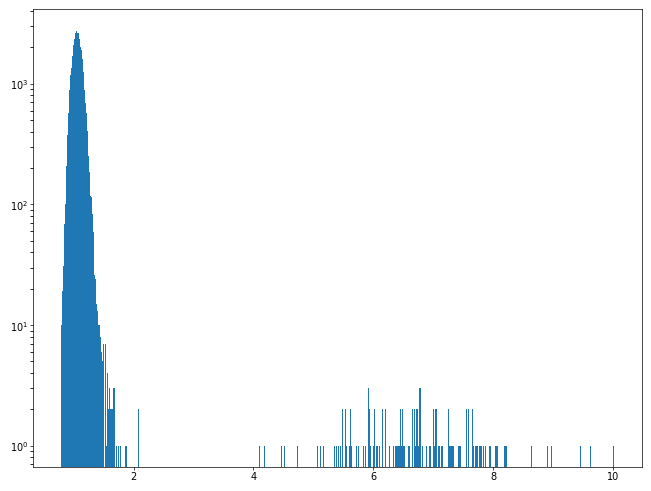

In [6]:
plt.hist(exemplar['chi_sqr'], 1000);
plt.yscale('log')
plt.show()

In [7]:
# Quality filters
chi_val = 2.0
max_localisation_error = 1.5   # pixels
max_colour_error = 0.15
min_photons = 100
max_photons = 1e6

# Linking parameters
max_distance = 10.0    # pixels — maximum spatial jump per frame. This corresponds to half a micron in 50 ms
max_dark_time = 5     # frames — maximum gap before track is terminated

# Spectral weighting
w_spatial = 1.0       # weight for spatial cost term
w_spectral = 1.0      # weight for spectral cost term
spectral_tol = 0.25   # normalisation scale for spectral distance

## 3. Run spectral LAP linking — all FOVs

Loop over every localisation file, link each independently, tag with the full file path
as `fov_name`, offset `molecular_index` to be globally unique, then concatenate into
combined single-molecule (`sm_db_all`) and single-frame (`sf_db_all`) databases.

In [8]:
all_sm = []
all_sf = []
running_idx_offset = 0
min_frames = 10

for f in localisation_files:
    fov_name = f  # full path as unique FOV identifier
    print(f"Processing: {os.path.basename(f)}")

    loc_data = pd.read_hdf(f)

    sm, sf = SM_E.extract_single_molecules_spectral_lap(
        loc_data.copy(),
        max_distance=max_distance,
        max_dark_time=max_dark_time,
        w_spatial=w_spatial,
        w_spectral=w_spectral,
        spectral_tol=spectral_tol,
        chi_val=chi_val,
        max_localisation_error=max_localisation_error,
        max_colour_error=max_colour_error,
        min_photons=min_photons,
        max_photons=max_photons,
        min_frames=min_frames,
        verbose=False,
    )

    if len(sm) == 0:
        print(f"  -> 0 molecules (skipped)")
        continue

    sm["molecular_index"] += running_idx_offset
    sf["molecular_index"] += running_idx_offset
    sm["fov_name"] = fov_name
    sf["fov_name"] = fov_name

    running_idx_offset = int(sm["molecular_index"].max()) + 1

    all_sm.append(sm)
    all_sf.append(sf)
    print(f"  -> {len(sm)} molecules")

sm_db = pd.concat(all_sm, ignore_index=True)
sf_db = pd.concat(all_sf, ignore_index=True)

print(f"\nTotal: {len(sm_db)} molecules from {sm_db['fov_name'].nunique()} FOVs")

Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 64 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 38 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.h5
  -> 115 molecules
Processing: 4banddichroic_NF_4_MMStack_Default.h5
  -> 125 molecules
Processing: 4banddichroic_NF_5_MMStack_Default.h5
  -> 61 molecules
Processing: 4banddichroic_NF_6_MMStack_Default.h5
  -> 75 molecules
Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 41 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 73 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.h5
  -> 102 molecules
Processing: 4banddichroic_NF_4_MMStack_Default.h5
  -> 67 molecules
Processing: 4banddichroic_NF_5_MMStack_Default.h5
  -> 73 molecules
Processing: 4banddichroic_NF_6_MMStack_Default.h5
  -> 49 molecules
Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 52 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 55 molecules
Processing: 4banddichroic_NF_3_MMStack_Defaul

In [13]:
# Normalise colour fractions to sum to 1 per molecule
colour_feat = sm_db[["A_R", "A_G", "A_B"]].to_numpy().astype(float)
row_sums = colour_feat.sum(axis=1, keepdims=True)
colour_norm = colour_feat / np.where(row_sums > 0, row_sums, 1.0)

# Fit KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(colour_norm)

# Order clusters by ascending mean A_R: 0 = bluest (AF488), 2 = reddest (JF646)
mean_AR = [colour_norm[labels == k, 0].mean() for k in range(3)]
order = np.argsort(mean_AR)   # indices of clusters sorted low→high A_R
remap = {int(old): int(new) for new, old in enumerate(order)}
sm_db["colour_cluster"] = np.array([remap[l] for l in labels], dtype=int)

# Propagate cluster labels to sf_db via molecular_index
cluster_map = sm_db.set_index("molecular_index")["colour_cluster"]
sf_db["colour_cluster"] = sf_db["molecular_index"].map(cluster_map)

print("Molecules per cluster:")
print(sm_db["colour_cluster"].value_counts().sort_index())

Molecules per cluster:
colour_cluster
0    215
1    116
2    136
Name: count, dtype: int64


In [10]:
# --- USER: set physical parameters ---
pixel_size_nm  = 69.0    # nm per pixel
frame_time_s   = 0.5     # seconds per frame
R_blur         = 1.0 / 6 # motion blur coefficient
min_frames_cve = 5       # minimum track length for D estimate

# Compute DSigma2_OLSF for every molecule and add D to sm_db
D_vals     = np.full(len(sm_db), np.nan)
sigma_vals = np.full(len(sm_db), np.nan)

for i, (_, row) in enumerate(sm_db.iterrows()):
    track = sf_db[sf_db["molecular_index"] == row["molecular_index"]].sort_values("frame")
    if len(track) < min_frames_cve:
        continue
    coords = np.column_stack([
        track["xc"].to_numpy() * pixel_size_nm,
        track["yc"].to_numpy() * pixel_size_nm,
    ])
    D, sigma = msd.DSigma2_OLSF(coords, frame_time_s, R=R_blur, n_d=2,
                                min_points=min_frames_cve)
    D_vals[i]     = D / 1e6   # nm²/s → µm²/s
    sigma_vals[i] = sigma

sm_db["D_um2_s"]  = D_vals
sm_db["sigma_nm"] = sigma_vals

# Filter to mobile molecules: finite D in physically plausible range
mobile_mask = sm_db["D_um2_s"].notna() & (sm_db["D_um2_s"] > 1e-4) & (sm_db["D_um2_s"] < 1000)
n_total  = len(sm_db)
sm_db = sm_db[mobile_mask].reset_index(drop=True)
sf_db = sf_db[sf_db["molecular_index"].isin(sm_db["molecular_index"])].copy()

print(f"Mobile: {len(sm_db)} / {n_total} molecules "
      f"({100*len(sm_db)/n_total:.1f}%) — static/unresolved discarded")
print(f"D range: {sm_db['D_um2_s'].min():.4f} – {sm_db['D_um2_s'].max():.3f} µm²/s")

Mobile: 467 / 605 molecules (77.2%) — static/unresolved discarded
D range: 0.0001 – 0.231 µm²/s


## 4. Inspect the results

/tmp/ipykernel_2519161/3732874691.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


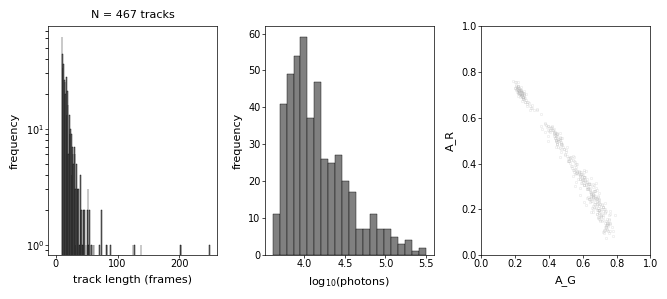

In [11]:
# Track length distribution
track_lengths = sf_db.groupby("molecular_index").size()

fig, axs = plotter.two_column_plot(ncols=3)

# Track lengths
bins = np.arange(0.5, track_lengths.max() + 1.5, 1)
axs[0].hist(track_lengths, bins=bins, color="gray", edgecolor="black", linewidth=0.3)
axs[0].set_xlabel("track length (frames)")
axs[0].set_ylabel("frequency")
axs[0].set_yscale('log')
axs[0].set_title(f"N = {len(track_lengths)} tracks")

# Photons per molecule
bins_ph = np.histogram_bin_edges(np.log10(sm_db["photons"].to_numpy()), "sqrt")
axs[1].hist(np.log10(sm_db["photons"]), bins=bins_ph, color="gray", edgecolor="black", linewidth=0.3)
axs[1].set_xlabel(r"log$_{10}$(photons)")
axs[1].set_ylabel("frequency")

# Colour distribution (per molecule)
axs[2].scatter(sm_db["A_G"], sm_db["A_R"], s=3, alpha=0.25, c="white", edgecolors="gray", linewidth=0.3)
axs[2].set_xlabel("A_G")
axs[2].set_ylabel("A_R")
axs[2].set_xlim([0, 1])
axs[2].set_ylim([0, 1])

plt.tight_layout()
#plt.savefig('For_Dan.svg', dpi=600, format='svg')
plt.show()

## 5. Visualise trajectories

Plot spatial trajectories coloured by their average RGB values.

In [12]:
len(sm_db)

467

## 9. Colour clustering

Assign each molecule to one of three colour clusters using KMeans on normalised
(A_R, A_G, A_B). Clusters are ordered by mean A_R so that:
- **Cluster 0** → lowest A_R (AF488, blue channel dominant)
- **Cluster 1** → intermediate (AF555, green channel dominant)
- **Cluster 2** → highest A_R (JF646, red channel dominant)

The sanity-check scatter (A_R vs A_G) should show three well-separated clouds.

In [ ]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

# Recompute colour_norm from filtered sm_db (mobile molecules only)
colour_feat = sm_db[["A_R", "A_G", "A_B"]].to_numpy().astype(float)
row_sums = colour_feat.sum(axis=1, keepdims=True)
colour_norm_plot = colour_feat / np.where(row_sums > 0, row_sums, 1.0)

import matplotlib.colors as mcolors
rgba_colors = np.array([mcolors.to_rgba(cluster_colors[k])
                        for k in sm_db["colour_cluster"]])

fig, ax = plotter.create_ternary_plot(
    colour_norm_plot[:, 0], colour_norm_plot[:, 1], colour_norm_plot[:, 2],
    colors=rgba_colors, marker_size=3, marker_alpha=0.4,
    title="Colour clusters (KMeans, k=3) — mobile molecules",
    labels={"R": "A_R", "G": "A_G", "B": "A_B"},
    figsize=(3, 3), rasterized=True,
)
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
fig.savefig(os.path.join(folder, 'Colour_Clusters.svg'), dpi=600, format='svg',
            bbox_inches='tight')
plt.show()

/tmp/ipykernel_2519161/283920250.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  color = cluster_colors[int(sm_db[sm_db['molecular_index'] == mol_idx]['colour_cluster'].values)]


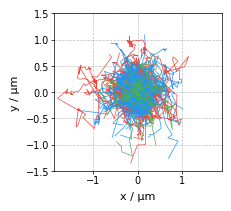

In [94]:
fig, ax = plotter.one_column_plot(height=2, width=2.2)
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red

pixel_size = 69
for mol_idx in np.unique(sm_db["molecular_index"].values):
    track = sf_db[sf_db["molecular_index"] == mol_idx].sort_values("frame")
    if len(track) < 11:
        continue
    color = cluster_colors[int(sm_db[sm_db['molecular_index'] == mol_idx]['colour_cluster'].values)]
    # Use track colour as line colour
    ax.plot(0.069*(track["xc"]-np.median(track["xc"])), 0.069*(track["yc"]-np.median(track["yc"])), lw=0.5, alpha=1, color=color)

ax.set_xlabel("x / µm")
ax.set_ylabel("y / µm")
ax.grid(True, color='gray', lw=0.5, alpha=0.5, ls='--')
#ax.set_xlim([500, 550])
#ax.set_ylim([50, 100])
ax.set_xlim([-1.9, 1.9])
ax.set_ylim([-1.5, 1.5])
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'All_Tracks_Overlayed.svg'), dpi=600,
            format='svg', bbox_inches='tight')
plt.show()

In [16]:
def gen_MSD(XY):
    """Compute MSD from 2D trajectory using the FFT method.

    Args:
        XY: (2, N) array — row 0 = x, row 1 = y (any units)

    Returns:
        MSD values for lag times 1..N-1 (same units squared)
    """
    r = XY.T  # msd_fft expects shape (N, n_d)
    return msd.msd_fft(r)


/tmp/ipykernel_2519161/1884347678.py:45: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


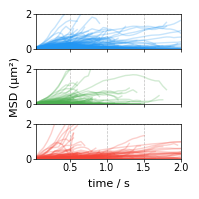

In [102]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red

pixel_size_um = 0.069   # µm per pixel
frame_time_s  = 0.05    # seconds per frame
min_msd_len   = 11     # minimum track length

fig, ax = plotter.one_column_plot(npanels=3, height=2, width=2)

for _, row in sm_db.iterrows():
    mol_idx = row["molecular_index"]
    track = sf_db[sf_db["molecular_index"] == mol_idx].sort_values("frame")
    if len(track) < min_msd_len:
        continue
    i = int(row["colour_cluster"])
    color = cluster_colors[int(row["colour_cluster"])]
    x_um = track["xc"].values * pixel_size_um
    y_um = track["yc"].values * pixel_size_um
    msd_vals = gen_MSD(np.vstack([x_um, y_um]))
    lag_times = np.arange(1, len(msd_vals) + 1) * frame_time_s
    ax[i] = plotter.line_plot(ax[i], lag_times, msd_vals, color=color, alpha=0.25,
            linewidth=1)

for i in np.arange(3):
    ax[i].set_xlim([0.05, 2])
    #ax[i].set_xscale('log')
    ax[i].set_ylim([0, 2])
    ax[i].grid(True, color='gray', lw=0.5, alpha=0.5, ls='--')
    if i != 2:
        ax[i].set_xlabel('')
        ax[i].set_xticklabels('')
    else:
        ax[i].set_xlabel('time / s')
    if i == 1:
        ax[i].set_ylabel("MSD (µm²)")
    else:
        ax[i].set_ylabel('')
        
#ax.set_xlim([0.05, 20])
#ax.set_xscale('log')
#ax.set_xlabel("lag time (s)")
#ax.set_ylabel("MSD (µm²)")
#ax.set_xlim(left=0)
#ax.set_ylim(bottom=0)

plt.tight_layout()
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'MSD_per_molecule.svg'), dpi=600,
            format='svg', bbox_inches='tight')
plt.show()

## 10. Diffusion coefficient distribution

D (µm²/s) was estimated per molecule using `DSigma2_OLSF` immediately
after linking (above) and used to filter out static molecules.
Plot the distribution per colour cluster.

/tmp/ipykernel_2519161/2491284474.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


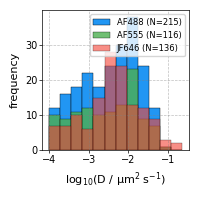

In [103]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

import seaborn as sns

df_plot = sm_db[["colour_cluster", "D_um2_s"]].dropna()
bins = np.histogram_bin_edges(np.log10(df_plot["D_um2_s"]), "fd")
alphas=[1, 0.8, 0.6]
fig, ax = plotter.one_column_plot(npanels=1, height=2, width=2)
for k, (color, name) in enumerate(zip(cluster_colors, cluster_names)):
    vals = np.log10(df_plot.loc[df_plot["colour_cluster"] == k, "D_um2_s"])
    ax.hist(vals, bins=bins, color=color, alpha=alphas[k],
            edgecolor="black", linewidth=0.3, label=f"{name} (N={len(vals)})")
ax.set_xlabel(r"log$_{10}$(D / µm$^2$ s$^{-1}$)")
ax.set_ylabel("frequency")
ax.legend(fontsize=6)
ax.grid(True, color='gray', lw=0.5, alpha=0.5, ls='--')
plt.tight_layout()
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'D_distribution.svg'), dpi=600,
            format='svg', bbox_inches='tight')
plt.show()

/tmp/ipykernel_2519161/200480707.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


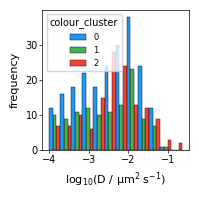

In [29]:
cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]   # blue, green, red
cluster_names  = ["AF488", "AF555", "JF646"]

import seaborn as sns

df_plot = sm_db[["colour_cluster", "D_um2_s"]].dropna()
bins = np.histogram_bin_edges(np.log10(df_plot["D_um2_s"]), "fd")
df_plot['D_um2_s_log'] = np.log10(df_plot['D_um2_s'])

fig, ax = plotter.one_column_plot(npanels=1, height=2, width=2)
sns.histplot(data=df_plot, x='D_um2_s_log', hue='colour_cluster',
             bins=bins, multiple='dodge', edgecolor='black', linewidth=0.3,
             palette=cluster_colors, alpha=1, ax=ax)
ax.set_xlabel(r"log$_{10}$(D / µm$^2$ s$^{-1}$)")
ax.set_ylabel("frequency")
plt.tight_layout()
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'D_distribution.svg'), dpi=600,
            format='svg', bbox_inches='tight')
plt.show()

## 11. Raw image overlay

Load the raw TIFF for one FOV, max-project the first 100 frames, and overlay
single-molecule positions as open circles coloured by their `colour_cluster` identity.
Change `fov_index` to inspect a different field of view.

In [ ]:
# --- USER: choose FOV and molecule ---
fov_index         = 4   # index into localisation_files
mol_display_index = 0   # index into molecules found in this FOV
track_frame_idx   = None  # None = middle frame of track; or set an int

fov_to_show = localisation_files[fov_index]

tiff_path = fov_to_show.replace(".h5", ".ome.tif")
if not os.path.exists(tiff_path):
    tiff_path = fov_to_show.replace(".h5", ".tif")

# Select molecule and its track
sm_fov = sm_db[sm_db["fov_name"] == fov_to_show].reset_index(drop=True)
sf_fov = sf_db[sf_db["fov_name"] == fov_to_show]

mol_row = sm_fov.iloc[mol_display_index]
mol_idx = int(mol_row["molecular_index"])
track   = sf_fov[sf_fov["molecular_index"] == mol_idx].sort_values("frame")

# Pick which frame to display
fi = len(track) // 2 if track_frame_idx is None else track_frame_idx
display_frame = int(track["frame"].iloc[fi])
loc_at_frame  = track[track["frame"] == display_frame]

# Load that raw frame
img = IO.read_tiff(tiff_path, frame=display_frame)

cluster_colors = ["#2196F3", "#4CAF50", "#F44336"]
color = cluster_colors[int(mol_row["colour_cluster"])]

fig, ax = plotter.create_figure(figsize=(2, 2))
ax = plotter.image_plot(ax, img, cmap="gray",
          vmin=np.percentile(img, 1), vmax=np.percentile(img, 99),
          origin="upper", scalebarsize=1000, scalebarlabel='1 μm',
          scalebar=True, pixelsize=69)
ax = ax[0]

# Track line
ax.plot(track["xc"].values, track["yc"].values,
        color=color, linewidth=0.5, alpha=0.6, zorder=1)

# Localisation at displayed frame (filled marker)
ax.scatter(loc_at_frame["xc"], loc_at_frame["yc"],
           s=40, color=color, marker="x", linewidths=1.5, zorder=3)

# Median position (open circle)
ax.scatter([mol_row["xc"]], [mol_row["yc"]], s=75,
           facecolors="none", edgecolors=color, linewidths=1, zorder=2)

# Auto-zoom to track extent with padding
pad = 20
ax.set_xlim([track["xc"].min() - pad, track["xc"].max() + pad])
ax.set_ylim([track["yc"].min() - pad, track["yc"].max() + pad])

ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_title(f"mol {mol_idx}, frame {display_frame}, "
             f"D={mol_row['D_um2_s']:.4f} µm²/s")
plt.tight_layout()
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks/Tracking'
plt.savefig(os.path.join(folder, 'Single_Molecule_Frame.svg'), dpi=600,
            format='svg', bbox_inches='tight')
plt.show()

In [53]:
mol_subset["xc"].values[0]

658.486328125

## 8. Save results

In [ ]:
# Save combined single-molecule and single-frame databases
output_folder = data_folder

sm_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_molecules.h5"),
    key="data", format="table",
)
sf_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_frames.h5"),
    key="data", format="table",
)

print(f"Saved to {output_folder}")
print(f"  spectral_lap_single_molecules.h5  ({len(sm_db)} molecules from {sm_db['fov_name'].nunique()} FOVs)")
print(f"  spectral_lap_single_frames.h5     ({len(sf_db)} localisations)")